In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda')
device

device(type='cuda')

In [2]:
!nvidia-smi

Thu Jul 10 13:25:12 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 545.23.08              Driver Version: 545.23.08    CUDA Version: 12.3     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA H100 NVL                On  | 00000000:4A:00.0 Off |                    0 |
| N/A   31C    P0              87W / 400W |    821MiB / 95830MiB |      0%      Default |
|                                         |                      |             Disabled |
+-----------------------------------------+----------------------+--

In [3]:
seed = 42
C = np.inf

In [4]:
# make sources
z_01 = np.linspace(0, 1, 32)

# modify density
z_01 = z_01 ** 2

z_01 = np.meshgrid(z_01, z_01)
z_01 = np.stack(z_01, 0).reshape(2, -1).T
z_01 = np.concatenate([z_01, np.zeros_like(z_01[:, :1])], 1)

z_02 = np.stack([z_01[:, 0], z_01[:, 2], z_01[:, 1]], 1)
z_12 = np.stack([z_01[:, 2], z_01[:, 0], z_01[:, 1]], 1)

z_01.shape, z_02.shape, z_12.shape

((1024, 3), (1024, 3), (1024, 3))

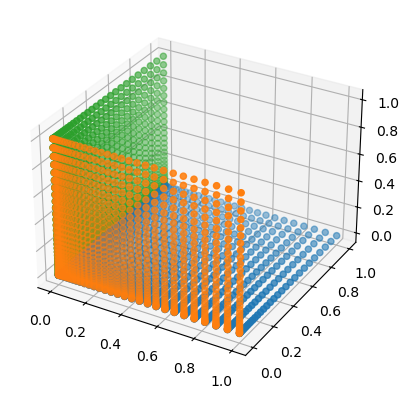

In [5]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(*z_01.T)
ax.scatter(*z_02.T)
ax.scatter(*z_12.T)

In [6]:
# random down projection
np.random.seed(42 + 0)
A = np.random.normal(0, 1, (3, 2))

# nice, clean, down projection
# A = np.array((
#     (1, 0),
#     (np.cos(2*np.pi/3), np.sin(2*np.pi/3)),
#     (np.cos(2*np.pi/3*2), np.sin(2*np.pi/3*2)),
# ))

In [7]:
# make observations

## mixing in 2d
y_01 = z_01 @ A
y_02 = z_02 @ A
y_12 = z_12 @ A

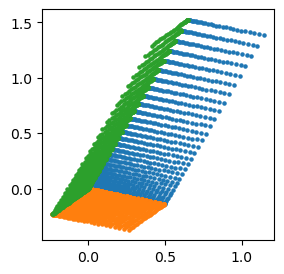

In [8]:
s = 5
plt.figure(figsize=(3, 3))
plt.scatter(*y_01.T, s=s)
plt.scatter(*y_02.T, s=s)
plt.scatter(*y_12.T, s=s)

In [9]:
# train A (linear encoder, nonlinear decoder)
num_seed = 10

inputs = np.concatenate([z_01, z_12, z_02], 0)
inputs = torch.tensor(inputs, dtype=torch.float32, device=device)

best_loss = np.inf
A = None

for rep in range(num_seed):
    torch.manual_seed(seed + rep)
    # MLP gets perfect
    encoder = nn.Linear(3, 2, bias=False).to(device)
    decoder = nn.Sequential(nn.Linear(2, 256), nn.ReLU(), nn.Linear(256, 3)).to(device)
    optim = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-3)

    for i in tqdm(range(10000)):
        y = encoder(inputs)
        rec = decoder(y)
        loss = torch.mean((inputs - rec) **2 )
        optim.zero_grad()
        loss.backward()
        optim.step()
    print(rep, i, loss.item())
    if loss.item() < best_loss:
        best_loss = loss.item()
        A = encoder.weight.detach().cpu().numpy().T
        if best_loss < 1e-4:
            break

100%|██████████| 10000/10000 [00:04<00:00, 2175.74it/s]

0 9999 1.1113722393929493e-05


In [10]:
A /= np.linalg.norm(A, axis=1, keepdims=True)

In [11]:
# make observations
y_01 = z_01 @ A
y_02 = z_02 @ A
y_12 = z_12 @ A

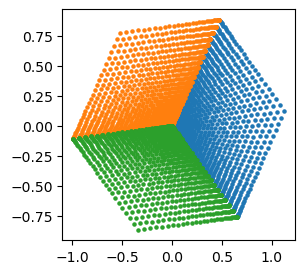

In [12]:
s = 5
plt.figure(figsize=(3, 3))
plt.scatter(*y_01.T, s=s)
plt.scatter(*y_02.T, s=s)
plt.scatter(*y_12.T, s=s)

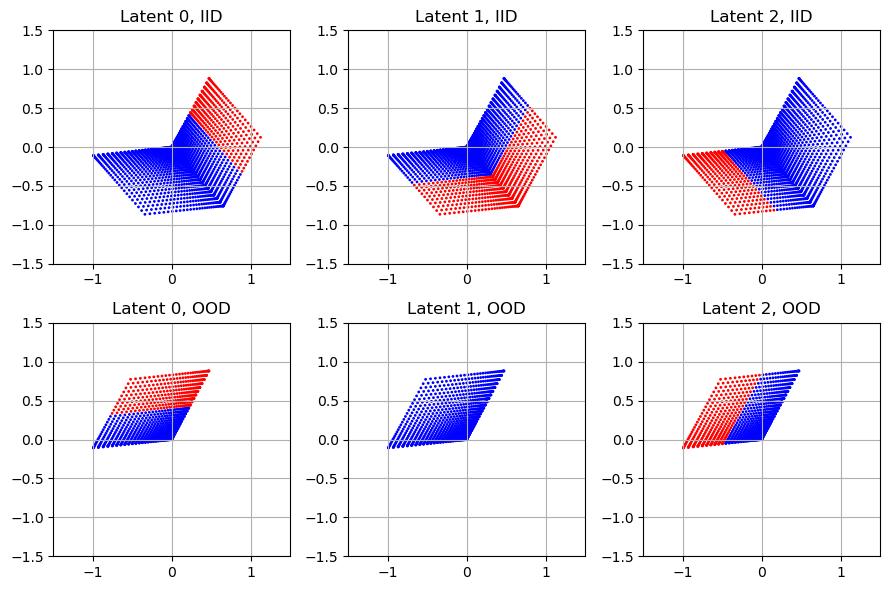

In [13]:
z_iid = np.concatenate([z_01, z_12], 0)
z_ood = z_02
y_iid = z_iid @ A
y_ood = z_ood @ A

label_iid = z_iid > .5
label_ood = z_ood > .5

dum = 1.5
xlim = (-dum, dum)
ylim = (-dum, dum)

s = 1

plt.figure(figsize=(9, 6))
for i in range(3):
    plt.subplot(2, 3, 1 + i)
    plt.scatter(*y_iid.T, c=label_iid[:, i], s=s, cmap='bwr')
    plt.grid()
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.title('Latent %s, IID' % i)
    
    plt.subplot(2, 3, 4 + i)
    plt.scatter(*y_ood.T, c=label_ood[:, i], s=s, cmap='bwr')
    plt.grid()
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.title('Latent %s, OOD' % i)

plt.tight_layout()
plt.show()

## latent 0: z_1 in 3d space (orthogonal vectors)
## red: class A
## blue: class B
## upper row: training set (designed IID)
## lower row: test set (designed OOD)


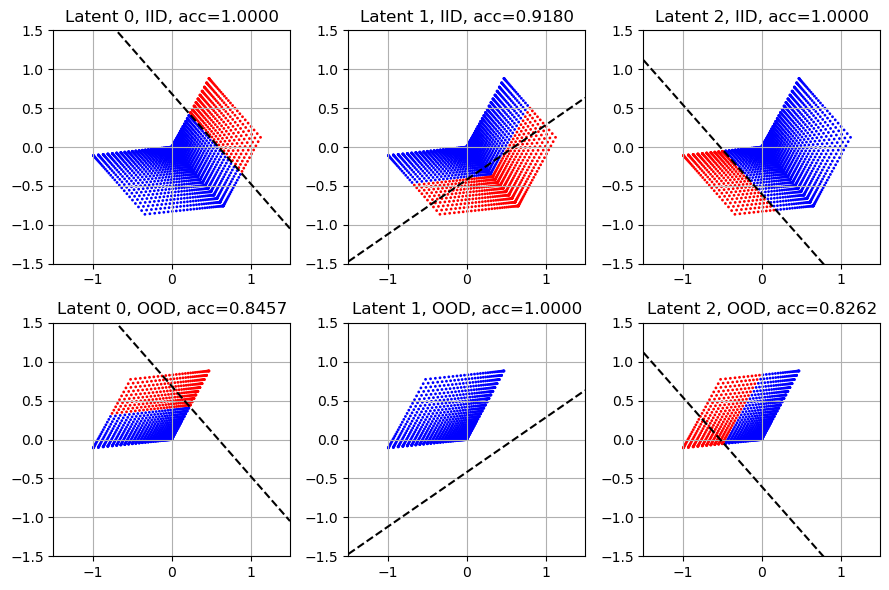

In [14]:
# linear probes
plt.figure(figsize=(9, 6))
for i in range(3):
    # Assume y is shape (N, 2) and label[:, 0] is binary (shape: N,)
    clf = LogisticRegression(C=C).fit(y_iid, label_iid[:, i])
    
    # Extract weights and bias
    w = clf.coef_[0]   # shape (2,)
    b = clf.intercept_[0]
    
    # Decision boundary: w₀ * x + w₁ * y + b = 0 → y = -(w₀/w₁)x - b/w₁
    x_vals = np.linspace(*xlim, 100)
    y_vals = -(w[0] / w[1]) * x_vals - b / w[1]
    
    # Plot data and boundary
    plt.subplot(2, 3, 1 + i)
    plt.scatter(*y_iid.T, c=label_iid[:, i], s=s, cmap='bwr')
    plt.plot(x_vals, y_vals, 'k--', label='Decision boundary')
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.grid()
    plt.title('Latent %s, IID, acc=%.4f' % (
        i, clf.score(y_iid, label_iid[:, i]))
    )
    
    plt.subplot(2, 3, 4 + i)
    plt.scatter(*y_ood.T, c=label_ood[:, i], s=s, cmap='bwr')
    plt.plot(x_vals, y_vals, 'k--', label='Decision boundary')
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.grid()
    plt.title('Latent %s, OOD, acc=%.4f' % (
        i, clf.score(y_ood, label_ood[:, i]))
    )
    
plt.tight_layout()
plt.show()

First interesting takeaway: Column 2 does not work IID because of this superposition setting. 
Threshold on z_2 results in this decision boundary that is a combination of 2 linear decision boundaries.

# Logistic regression in original 3d z space

In [15]:
for ind in range(3):
    clf = LogisticRegression(C=C).fit(z_iid, label_iid[:, ind])
    
    acc_iid = clf.score(z_iid, label_iid[:, ind])
    acc_ood = clf.score(z_ood, label_ood[:, ind])
    print(f'index {ind}, acc IID: {acc_iid:.3f}, acc OOD: {acc_ood:.3f}')

index 0, acc IID: 1.000, acc OOD: 1.000
index 1, acc IID: 1.000, acc OOD: 1.000
index 2, acc IID: 1.000, acc OOD: 1.000


I would like to draw the decision boundaries in this 3d case

In [16]:
# fig = plt.figure()
# ax = fig.add_subplot(projection='3d')
# # ax.scatter(*target.detach().cpu().numpy().T, s=s, c=label_ood)

# y_vals = np.linspace(*ylim, 100)
# x,y = np.meshgrid(x_vals,y_vals)
# z = lambda x,y: (-clf.intercept_[0]-clf.coef_[0][0]*x-clf.coef_[0][1]*y) / clf.coef_[0][2]
# ax.plot_surface(x, y, z(x,y))

elev = 30
azim = 30
roll = 0
# ax.view_init(elev, azim, roll)
# plt.show()

In [17]:
# fig = plt.figure()
# ax = fig.add_subplot(projection='3d')
# ax.scatter(z_iid, s=s, c=label_iid)

# # y_vals = np.linspace(*ylim, 100)
# # x,y = np.meshgrid(x_vals,y_vals)
# # z = lambda x,y: (-clf.intercept_[0]-clf.coef_[0][0]*x-clf.coef_[0][1]*y) / clf.coef_[0][2]
# # ax.plot_surface(x, y, z(x,y))

# elev = 30
# azim = 30
# roll = 0
# ax.view_init(elev, azim, roll)
# plt.show()

# SAE

In [18]:
z_iid = torch.tensor(z_iid, dtype=torch.float32, device=device)
y_iid = torch.tensor(y_iid, dtype=torch.float32, device=device)

In [19]:
y_iid.shape

torch.Size([2048, 2])

In [20]:
z_iid.shape

torch.Size([2048, 3])

In [21]:
num_seed = 3

target = np.concatenate([z_01, z_12, z_02], 0)
inputs = target @ A
inputs = torch.tensor(inputs, dtype=torch.float32, device=device)
target = torch.tensor(target, dtype=torch.float32, device=device)

best_loss = np.inf
z_ = None

for rep in range(num_seed):
    torch.manual_seed(seed + rep)
    # SAE encoder:
    model = nn.Sequential(nn.Linear(2, 3), nn.Softplus()).to(device)
    # MLP gets perfect
    # model = nn.Sequential(nn.Linear(2, 256), nn.ReLU(), nn.Linear(256, 3)).to(device)
    decoder = nn.Linear(3, 2).to(device)
    optim = torch.optim.Adam(list(model.parameters()) + list(decoder.parameters()), lr=1e-3)

    for i in tqdm(range(10000)):
        # pred = model(inputs[:z_01.shape[0] * 2]) # train on iid
        pred = model(y_iid)
        
        # supervised
        # mse = torch.mean((target[:z_01.shape[0] * 2] - pred)**2)
        mse = torch.mean((z_iid - pred)**2)
        l1 = 0
        loss = mse
        
        # # unsup
        # rec = decoder(pred)
        # mse = torch.mean((inputs[:z_01.shape[0] * 2] - rec)**2)
        # l1 = torch.mean(torch.abs(pred) * torch.linalg.norm(decoder.weight, dim=0))
        # loss = mse + 1e-1 * l1
        
        optim.zero_grad()
        loss.backward()
        optim.step()
    print(rep, i, mse.item(), l1)
    if loss.item() < best_loss:
        best_loss = loss.item()
        # pred = model(inputs) # predict all
        pred = model(y_iid) # predict all
        z_ = pred.detach().cpu().numpy()

100%|██████████| 10000/10000 [00:03<00:00, 3331.67it/s]


0 9999 0.009379548951983452 0


100%|██████████| 10000/10000 [00:03<00:00, 3320.00it/s]


1 9999 0.009378457441926003 0


100%|██████████| 10000/10000 [00:03<00:00, 3317.15it/s]

2 9999 0.009381558746099472 0


In [22]:
# fig = plt.figure()
# ax = fig.add_subplot(projection='3d')
# ax.scatter(*target.detach().cpu().numpy().T, s=s, c=label_ood)

# elev = 30
# azim = 30
# roll = 0
# ax.view_init(elev, azim, roll)
# plt.show()

In [23]:
# fig = plt.figure()
# ax = fig.add_subplot(projection='3d')
# ax.scatter(*target.detach().cpu().numpy().T, s=s, c=label_ood)
# elev = 30
# azim = 30
# roll = 0
# ax.view_init(elev, azim, roll)
# plt.show()

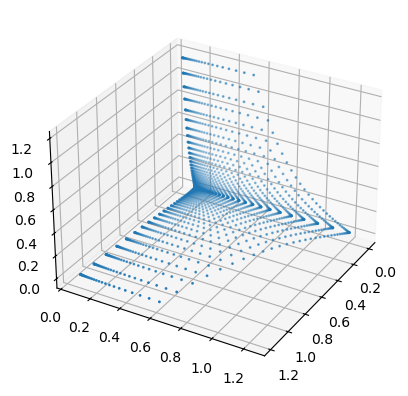

In [24]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(*z_.T, s=s)
ax.view_init(elev, azim, roll)
plt.show()

## Logistic regression in SAE

In [25]:
z_.shape

(2048, 3)

In [26]:
z_iid.shape

torch.Size([2048, 3])

In [30]:
label_iid.shape

(2048, 3)

In [31]:
z_.shape

(2048, 3)

In [32]:
z_iid.shape

torch.Size([2048, 3])

In [33]:
z_ood.shape

(1024, 3)

In [ ]:
# z_iid_sc = z_[:z_01.shape[0] *]
# z_ood_sc = z_[z_01.shape[0] * 2:]

for ind in range(3):
    clf = LogisticRegression(C=C).fit(z_, label_iid[:, ind])
    
    acc_iid = clf.score(z_, label_iid[:, ind])
    # acc_ood = clf.score(z_ood_sc, label_ood[:, ind])
    # print(f'index {ind}, acc IID: {acc_iid:.3f}, acc OOD: {acc_ood:.3f}')

ValueError: y should be a 1d array, got an array of shape (2048, 3) instead.

In [ ]:
z_iid_sc = z_[:z_01.shape[0] * 2]
z_ood_sc = z_[z_01.shape[0] * 2:]

for ind in range(3):
    clf = LogisticRegression(C=C).fit(z_iid_sc, label_iid[:, ind])
    
    acc_iid = clf.score(z_iid_sc, label_iid[:, ind])
    acc_ood = clf.score(z_ood_sc, label_ood[:, ind])
    print(f'index {ind}, acc IID: {acc_iid:.3f}, acc OOD: {acc_ood:.3f}')

ValueError: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required by LogisticRegression.

In [ ]:
# fig = plt.figure()
# ax = fig.add_subplot(projection='3d')
# ax.scatter(*z_.T, s=s, c=label_ood)

# x,y = np.meshgrid(x_vals,y_vals)
# z = lambda x,y: (-clf.intercept_[0]-clf.coef_[0][0]*x-clf.coef_[0][1]*y) / clf.coef_[0][2]
# ax.plot_surface(x, y, z(x,y))

# elev = 30
# azim = 30
# roll = 0
# ax.view_init(elev, azim, roll)
# plt.show()

# Sparse inference (dictionary learning) -- supervised

In [ ]:
from sklearn.decomposition import DictionaryLearning
from sklearn.decomposition import sparse_encode

target = np.concatenate([z_01, z_12, z_02], 0)
inputs = target @ A

X_transformed = sparse_encode(inputs, A, algorithm='lasso_cd', alpha=0, positive=True)

X_transformed.shape, X_transformed.min()

/grid/klindt/home/barinpac/.conda/envs/pytorch-cuda/lib/python3.10/site-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/grid/klindt/home/barinpac/.conda/envs/pytorch-cuda/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: UserWarning: Coordinate descent without L1 regularization may lead to unexpected results and is discouraged. Set l1_ratio > 0 to add L1 regularization.
  model = cd_fast.enet_coordinate_descent_gram(
/grid/klindt/home/barinpac/.conda/envs/pytorch-cuda/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0, tolerance: 0.0
  model = cd_fast.enet_coordinate_descent_gram(


((3072, 3), np.float32(0.0))

NameError: name 'elev' is not defined

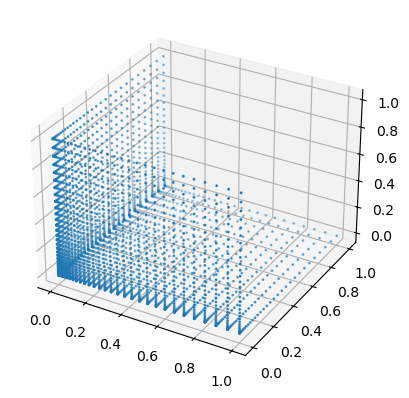

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(*X_transformed.T, s=s)
ax.view_init(elev, azim, roll)
plt.show()

In [ ]:
z_iid_sc.shape

(2048, 3)

In [ ]:
z_ood_sc.shape

(1024, 3)

In [ ]:
X_transformed.shape

(3072, 3)

In [ ]:
z_iid_sc = X_transformed[:z_01.shape[0] * 2]
z_ood_sc = X_transformed[z_01.shape[0] * 2:]

for ind in range(3):
    clf = LogisticRegression(C=C).fit(z_iid_sc, label_iid[:, ind])
    
    acc_iid = clf.score(z_iid_sc, label_iid[:, ind])
    acc_ood = clf.score(z_ood_sc, label_ood[:, ind])
    print(f'index {ind}, acc IID: {acc_iid:.3f}, acc OOD: {acc_ood:.3f}')

for ind in range(3):
    for j in range(3):
        clf = LogisticRegression(C=C).fit(z_iid_sc[:, j][:, None], label_iid[:, ind])
        
        acc_iid = clf.score(z_iid_sc[:, j][:, None], label_iid[:, ind])
        acc_ood = clf.score(z_ood_sc[:, j][:, None], label_ood[:, ind])
        print(j, f'index {ind}, acc IID: {acc_iid:.3f}, acc OOD: {acc_ood:.3f}')

index 0, acc IID: 1.000, acc OOD: 1.000
index 1, acc IID: 1.000, acc OOD: 1.000
index 2, acc IID: 1.000, acc OOD: 1.000
0 index 0, acc IID: 1.000, acc OOD: 1.000
1 index 0, acc IID: 0.844, acc OOD: 0.688
2 index 0, acc IID: 0.844, acc OOD: 0.688
0 index 1, acc IID: 0.688, acc OOD: 1.000
1 index 1, acc IID: 1.000, acc OOD: 1.000
2 index 1, acc IID: 0.688, acc OOD: 1.000
0 index 2, acc IID: 0.844, acc OOD: 0.688
1 index 2, acc IID: 0.844, acc OOD: 0.688
2 index 2, acc IID: 1.000, acc OOD: 1.000


In [ ]:
dict_learner = DictionaryLearning(
    n_components=3, 
    fit_algorithm='cd',
    transform_algorithm='lasso_cd', 
    transform_max_iter=100000,  # default is 1000
    transform_alpha=1e-6,
    random_state=42,
    verbose=True,
    positive_code=True,
    # tol=1e-9
)
X_transformed = dict_learner.fit_transform(inputs)

[dict_learning] .1 unused atoms resampled.
.

/grid/klindt/home/barinpac/.conda/envs/jhub-py312/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent_gram(
/grid/klindt/home/barinpac/.conda/envs/jhub-py312/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent_gram(


2 unused atoms resampled.
.2 unused atoms resampled.
.

/grid/klindt/home/barinpac/.conda/envs/jhub-py312/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent_gram(
/grid/klindt/home/barinpac/.conda/envs/jhub-py312/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent_gram(


2 unused atoms resampled.
.2 unused atoms resampled.



/grid/klindt/home/barinpac/.conda/envs/jhub-py312/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent_gram(


In [ ]:
X_transformed.max()

np.float64(0.1327252325294792)

NameError: name 'elev' is not defined

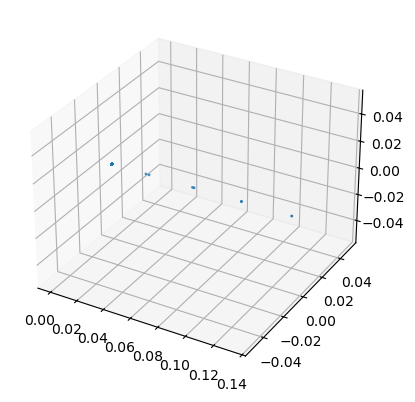

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(*X_transformed.T, s=s)
ax.view_init(elev, azim, roll)
plt.show()

## Logistic regression accuracy

In [ ]:
z_iid_sc = X_transformed[:z_01.shape[0] * 2]
z_ood_sc = X_transformed[z_01.shape[0] * 2:]

for ind in range(3):
    clf = LogisticRegression(C=C).fit(z_iid_sc, label_iid[:, ind])
    
    acc_iid = clf.score(z_iid_sc, label_iid[:, ind])
    acc_ood = clf.score(z_ood_sc, label_ood[:, ind])
    print(f'index {ind}, acc IID: {acc_iid:.3f}, acc OOD: {acc_ood:.3f}')

index 0, acc IID: 0.849, acc OOD: 0.688
index 1, acc IID: 0.692, acc OOD: 1.000
index 2, acc IID: 0.844, acc OOD: 0.688


# Unsupervised dicitonary learning

  0%|          | 0/100000 [00:00<?, ?it/s]

0 0 0.5214900374412537 0.6127370595932007


NameError: name 'elev' is not defined

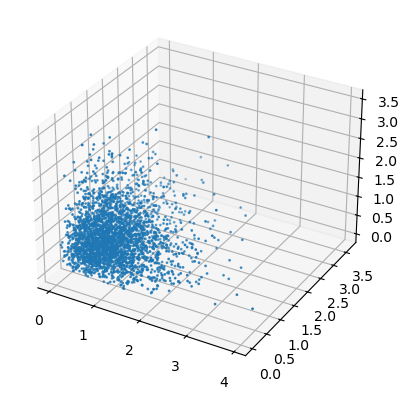

In [ ]:
num_seed = 1

target = np.concatenate([z_01, z_12, z_02], 0)
inputs = target @ A
inputs = torch.tensor(inputs, dtype=torch.float32, device=device)
target = torch.tensor(target, dtype=torch.float32, device=device)

best_loss = np.inf
best_D, best_Z = None, None

for rep in range(num_seed):
    torch.manual_seed(seed + rep)

    log_Z = torch.randn(inputs.shape[0], 3, device=device).requires_grad_()
    D = torch.randn(3, 2, device=device).requires_grad_()
    # D = torch.tensor(A, dtype=torch.float32, device=device)
    optim = torch.optim.Adam([log_Z, D], lr=1e-2)

    for i in tqdm(range(100000)):
        # Z = torch.exp(log_Z)
        Z = torch.nn.functional.softplus(log_Z)
        # Z = torch.nn.functional.relu(log_Z)
        # Z = torch.nn.functional.gelu(log_Z)
        rec = Z @ D
        mse = torch.mean((inputs - rec)**2)
        # l1 = torch.mean(Z)
        l1 = torch.mean(torch.abs(Z) * torch.linalg.norm(D, dim=1))
        loss = mse + 0.001 * l1
        optim.zero_grad()
        loss.backward()
        optim.step()

        # D.data /= torch.linalg.norm(D, dim=1, keepdim=True)
        
        if rep == 0 and not i % 10000:
            print(rep, i, mse.item(), l1.item())
            fig = plt.figure()
            ax = fig.add_subplot(projection='3d')
            ax.scatter(*Z.detach().cpu().numpy().T, s=s)
            ax.view_init(elev, azim, roll)
            plt.show()

        if i > 10000:
            if loss.item() > best_loss * 1.1:
                break
    print(rep, i, mse.item(), l1.item())
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.scatter(*Z.detach().cpu().numpy().T, s=s)
    ax.view_init(elev, azim, roll)
    plt.show()
    if loss.item() < best_loss:
        best_D = D.detach().cpu().numpy()
        best_Z = Z.detach().cpu().numpy()

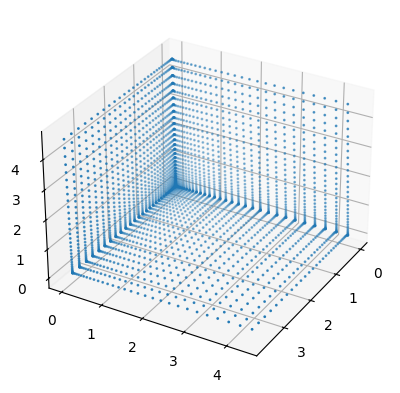

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(*best_Z.T, s=s)
ax.view_init(elev, azim, roll)
plt.show()

In [ ]:
z_iid_sc = best_Z[:z_01.shape[0] * 2]
z_ood_sc = best_Z[z_01.shape[0] * 2:]

for ind in range(3):
    clf = LogisticRegression(C=C).fit(z_iid_sc, label_iid[:, ind])
    
    acc_iid = clf.score(z_iid_sc, label_iid[:, ind])
    acc_ood = clf.score(z_ood_sc, label_ood[:, ind])
    print(f'index {ind}, acc IID: {acc_iid:.3f}, acc OOD: {acc_ood:.3f}')

index 0, acc IID: 1.000, acc OOD: 0.985
index 1, acc IID: 1.000, acc OOD: 1.000
index 2, acc IID: 1.000, acc OOD: 0.974


In [ ]:
torch.linalg.norm(D, dim=1), np.max(best_Z, 0)

(tensor([0.2751, 0.2302, 0.2207], device='cuda:0',
        grad_fn=<LinalgVectorNormBackward0>),
 array([3.720927, 4.378332, 4.579469], dtype=float32))

In [ ]:
z_iid_sc = best_Z[:z_01.shape[0] * 2]
z_ood_sc = best_Z[z_01.shape[0] * 2:]

for ind in range(3):
    for j in range(3):
        clf = LogisticRegression(C=C).fit(z_iid_sc[:, j][:, None], label_iid[:, ind])
        
        acc_iid = clf.score(z_iid_sc[:, j][:, None], label_iid[:, ind])
        acc_ood = clf.score(z_ood_sc[:, j][:, None], label_ood[:, ind])
        print(j, f'index {ind}, acc IID: {acc_iid:.3f}, acc OOD: {acc_ood:.3f}')

0 index 0, acc IID: 1.000, acc OOD: 1.000
1 index 0, acc IID: 0.844, acc OOD: 0.688
2 index 0, acc IID: 0.844, acc OOD: 0.688
0 index 1, acc IID: 0.688, acc OOD: 1.000
1 index 1, acc IID: 0.688, acc OOD: 1.000
2 index 1, acc IID: 1.000, acc OOD: 1.000
0 index 2, acc IID: 0.844, acc OOD: 0.688
1 index 2, acc IID: 1.000, acc OOD: 1.000
2 index 2, acc IID: 0.844, acc OOD: 0.688
